# 元学习PINN损失函数复现

本notebook使用MindSpore复现Psaros等人(2022)的"Meta-learning PINN loss functions"方法。

该论文提出了一种元学习技术，用于发现物理信息神经网络(PINN)的损失函数。我们实现了一个简化版本，以Burgers方程为例。

## 导入所需库

In [39]:
import warnings
import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops
import numpy as np
import matplotlib.pyplot as plt
from mindspore import Tensor
from mindspore.common import dtype as mstype
from mindspore.common.parameter import Parameter

ms.set_context(mode=ms.PYNATIVE_MODE)

## 加载和预处理数据

在本例中，我们为 Heat 方程生成合成数据：∂u/∂t = ν ∂²u/∂x²

我们使用配点法用于 PDE 残差和边界/初始条件。

In [40]:
# 生成配点
N_u = 200  # 边界/初始点数量
N_f = 5000  # 配点数量

# 域：x in [-1,1], t in [0,1]
x = np.linspace(-1, 1, 200).reshape(-1, 1)
t = np.linspace(0, 1, 200).reshape(-1, 1)
X, T = np.meshgrid(x, t)
X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

# 边界和初始条件
x_bc = np.array([[-1], [1]])
t_bc = np.random.rand(N_u // 2, 1)
X_bc = np.vstack((np.hstack((x_bc[0] * np.ones((N_u // 2, 1)), t_bc)),
                  np.hstack((x_bc[1] * np.ones((N_u // 2, 1)), t_bc))))

x_ic = np.linspace(-1, 1, N_u // 2).reshape(-1, 1)
t_ic = np.zeros((N_u // 2, 1))
X_ic = np.hstack((x_ic, t_ic))

X_u_train = np.vstack((X_bc, X_ic))

# 配点
idx = np.random.choice(X_star.shape[0], N_f, replace=False)
X_f_train = X_star[idx, :]

# Heat equation 的精确解（用于评估）
def exact_solution(x, t, nu=0.01/np.pi):
    return -np.sin(np.pi * x) * np.exp(-nu * np.pi**2 * t)

u_exact = exact_solution(X_star[:, 0], X_star[:, 1])

u_bc = exact_solution(X_bc[:, 0], X_bc[:, 1])
u_ic = exact_solution(X_ic[:, 0], X_ic[:, 1])

u_train = np.vstack((u_bc.reshape(-1, 1), u_ic.reshape(-1, 1)))

# 转换为MindSpore张量
X_u = Tensor(X_u_train, mstype.float32)
u = Tensor(u_train, mstype.float32)
X_f = Tensor(X_f_train, mstype.float32)

## 定义模型

我们定义一个简单的前馈神经网络来近似解u(x,t)。

In [41]:
class PINN(nn.Cell):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.layers = nn.SequentialCell()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Dense(layers[i], layers[i+1], activation=nn.Tanh() if i < len(layers)-2 else None))

    def construct(self, x):
        return self.layers(x)

# 网络架构
layers = [2, 50, 50, 50, 50, 1]  # 输入：x,t；输出：u
model = PINN(layers)

## 损失函数和元学习

元学习损失结合了数据损失和PDE残差损失。在这个简化实现中，我们学习不同损失组件的权重。

In [42]:
# 元学习损失权重（可学习参数），使用对数参数保证正权重
loss_weight_u = Parameter(Tensor(0.0, mstype.float32))
loss_weight_f = Parameter(Tensor(0.0, mstype.float32))

def net_u(x, t):
    return model(ops.concat((x, t), axis=1))

net_u_x = ms.grad(net_u, 0)
net_u_t = ms.grad(net_u, 1)
net_u_xx = ms.grad(net_u_x, 0)

class PINNLossCell(nn.Cell):
    def __init__(self, model, loss_weight_u, loss_weight_f):
        super(PINNLossCell, self).__init__()
        self.model = model
        self.loss_weight_u = loss_weight_u
        self.loss_weight_f = loss_weight_f
        # ... 其余不变
        self.exp = ops.Exp()

    def construct(self, X_u, u, X_f):
        # 数据损失
        x_u, t_u = X_u[:, 0:1], X_u[:, 1:2]
        u_pred = self.model(ops.concat((x_u, t_u), axis=1))
        loss_u = ops.ReduceMean()((u_pred - u) ** 2)

        # PDE 残差损失
        x_f, t_f = X_f[:, 0:1], X_f[:, 1:2]
        u_t = net_u_t(x_f, t_f)
        u_x = net_u_x(x_f, t_f)      # 如果有需要
        u_xx = net_u_xx(x_f, t_f)
        nu = Tensor(0.01 / np.pi, mstype.float32)
        f_pred = u_t - nu * u_xx
        loss_f = ops.ReduceMean()(f_pred ** 2)

        total_loss = self.exp(self.loss_weight_u) * loss_u + self.exp(self.loss_weight_f) * loss_f
        return total_loss

loss_cell = PINNLossCell(model, loss_weight_u, loss_weight_f)

## 训练模型

我们使用元学习损失函数训练PINN模型。

In [43]:
# 优化器
optimizer = nn.AdamWeightDecay(
    params=model.trainable_params() + [loss_weight_u, loss_weight_f],
    learning_rate=1e-4,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    weight_decay=0.0  # 按需调整
)
train_net = nn.TrainOneStepCell(loss_cell, optimizer)

# 训练循环
epochs = 1000
loss_history = []

for epoch in range(epochs):
    loss = train_net(X_u, u, X_f)
    loss_history.append(loss.asnumpy())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.asnumpy():.6f}")

print("训练完成。")
final_weights = ops.Exp()(ops.stack([loss_weight_u, loss_weight_f])).asnumpy()
print(f"最终损失权重: {final_weights}")

Epoch 0, Loss: 0.169737
Epoch 100, Loss: 0.131958
Epoch 200, Loss: 0.010713
Epoch 300, Loss: 0.002453
Epoch 400, Loss: 0.000972
Epoch 500, Loss: 0.000446
Epoch 600, Loss: 0.000276
Epoch 700, Loss: 0.000156
Epoch 800, Loss: 0.000149
Epoch 900, Loss: 0.000103
训练完成。
最终损失权重: [0.9377929  0.88060975]


## 评估模型

计算整个域上的预测误差。

In [44]:
# 在整个域上评估
X_star_tensor = Tensor(X_star, mstype.float32)
u_pred = model(X_star_tensor).asnumpy()

# 计算L2误差
error = np.linalg.norm(u_exact - u_pred.flatten(), 2) / np.linalg.norm(u_exact, 2)
print(f"L2相对误差: {error:.6f}")

# 计算损失组成
x_u, t_u = X_u[:, 0:1], X_u[:, 1:2]
u_pred_u = model(ops.concat((x_u, t_u), 1))
loss_u = np.mean((u_pred_u.asnumpy() - u.asnumpy()) ** 2)

x_f, t_f = X_f[:, 0:1], X_f[:, 1:2]
u_t = net_u_t(x_f, t_f)
u_xx = net_u_xx(x_f, t_f)
nu = Tensor(0.01 / np.pi, mstype.float32)
f_pred = u_t - nu * u_xx
loss_f = np.mean(f_pred.asnumpy() ** 2)

print(f"数据损失: {loss_u:.6f}")
print(f"PDE损失: {loss_f:.6f}")
print(f"最终总损失: {loss_cell(X_u, u, X_f).asnumpy():.6f}")

L2相对误差: 0.005268
数据损失: 0.000016
PDE损失: 0.000088
最终总损失: 0.000092


## 可视化结果

绘制训练损失和预测与精确解的对比。

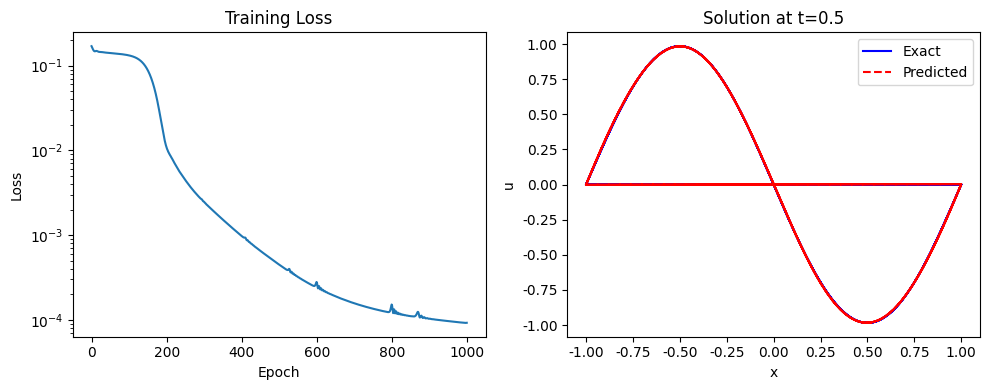

In [45]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Microsoft YaHei']
# 绘制训练损失
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.yscale('log')

# 在t=0.5时绘制解
plt.subplot(1, 2, 2)
idx_t = np.abs(T.flatten() - 0.5) < 0.01
plt.plot(X_star[idx_t, 0], u_exact[idx_t], 'b-', label='Exact')
plt.plot(X_star[idx_t, 0], u_pred[idx_t], 'r--', label='Predicted')
plt.xlabel('x')
plt.ylabel('u')
plt.title('Solution at t=0.5')
plt.legend()
plt.tight_layout()
plt.show()